in this notebook we're gonna use the data prepared in notebook "03" to work on :
- **an unsupervised learning:** To apply clustering algorithms to the female economic vulnerability indicators to identify distinct profiles of communes across Morocco.
- **supervised learning:** To build an interpretable regression model that explains the key structural drivers of the Female Economic Vulnerability Index (FEVI). We will use MLflow to track our modeling experiments

- **imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

import mlflow
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
import mlflow
mlflow.set_tracking_uri("file:///C:/Users/fadwa/hcp project/mlruns")
mlflow.set_experiment("TestExperiment")

with mlflow.start_run():
    mlflow.log_param("param1", 123)
    mlflow.log_metric("accuracy", 0.95)


- **mlflow set**

In [3]:
mlflow.set_experiment("My_Regression_Experiments")

<Experiment: artifact_location='file:///C:/Users/fadwa/hcp project/mlruns/720666321411971468', creation_time=1756329659636, experiment_id='720666321411971468', last_update_time=1756329659636, lifecycle_stage='active', name='My_Regression_Experiments', tags={}>

## Part 1: Unsupervised learning (clustering)

### 1-1 data loading for clustering

In [4]:
df_clustering = pd.read_csv('../data/communal_data_for_fevi_clustering.csv', index_col=0)

print("Clustering data loaded successfully.")
display(df_clustering.head())

Clustering data loaded successfully.


,Taux d'activité des 15 ans et plus (%)_FEMMES_TOTAL,Taux de chômage (%)_FEMMES_TOTAL,Statut professionnel des actifs occupés de 15 ans et plus (%)_Aide familial._FEMMES_TOTAL,Statut professionnel des actifs occupés de 15 ans et plus (%)_Indépendant._FEMMES_TOTAL,Taux d'analphabétisme des 15 ans et plus (%)_FEMMES_TOTAL,Niveau d'études dans l'enseignement général (%)_Aucun niveau d'études._FEMMES_TOTAL,Niveau d'études dans l'enseignement général (%)_Supérieur._FEMMES_TOTAL,État matrimonial des 15 ans et plus (%)_Veuf.ve._FEMMES_TOTAL,Âge moyen singulier au mariage_FEMMES_TOTAL
2,3.268917,-0.836978,-0.526621,-0.551452,-2.349759,-2.073817,2.061495,-1.193623,0.741122
7,1.938642,-0.113911,-0.469658,0.343553,-2.146329,-2.053170,1.928812,0.306105,1.031807
8,3.194182,-0.957490,-0.513962,-0.658196,-2.545654,-2.094464,1.743057,-1.909403,-0.213987
10,1.579917,-0.804112,-0.526621,-0.740307,-1.588782,-1.340843,-0.114497,-1.841233,-0.213987
11,0.369217,-1.291634,-0.438013,-0.370809,-0.601772,-0.514956,-0.114497,0.408359,0.782649


### 1-2 Determine the optimal number of cluster

- elbow method

In [5]:
inertia = []
K = range(1, 20)
for k in K:
    # n_init=10 => avoid bad random initializations
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clustering)
    inertia.append(kmeans.inertia_)

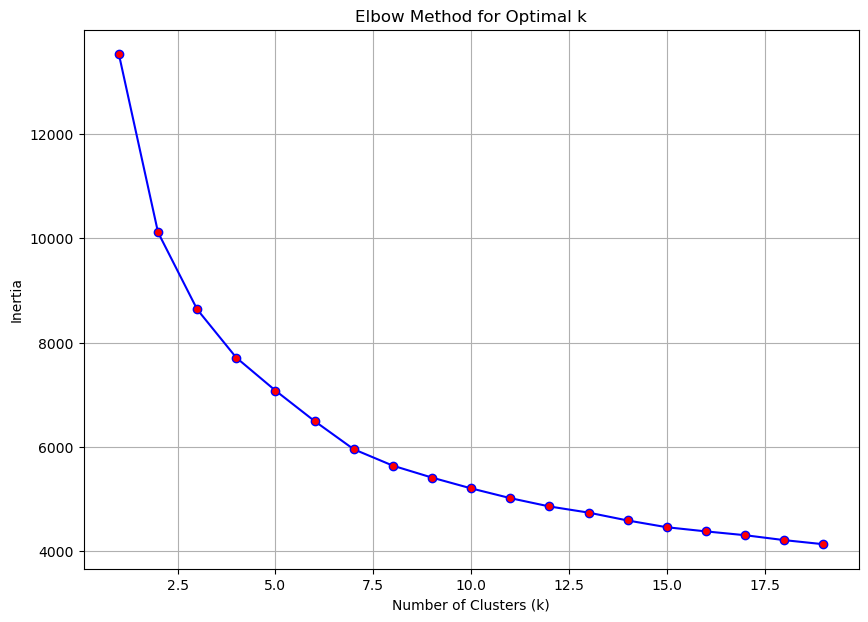

In [6]:
plt.figure(figsize=(10, 7))
plt.plot(K, inertia, 'bo-', markerfacecolor='r')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

### 1-3 Train Final Model 

optimal k : **4**

In [7]:
optimal_k = 4 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

- cluster labels

In [8]:
df_interpretation = pd.read_csv('../data/communal_data_for_fevi_clustering.csv', index_col=0) 
df_interpretation['Cluster'] = kmeans.fit_predict(df_clustering)

In [9]:
cluster_profiles = df_interpretation.groupby('Cluster').mean()

- Interpretation

In [10]:
print(f"Cluster Profiles (mean values for each feature):")
display(cluster_profiles.transpose())

Cluster Profiles (mean values for each feature):


Cluster,0,1,2,3
Taux d'activité des 15 ans et plus (%)_FEMMES_TOTAL,-0.679725,1.138850,-0.437934,0.388803
Taux de chômage (%)_FEMMES_TOTAL,0.090010,0.000633,0.160936,-0.708345
Statut professionnel des actifs occupés de 15 ans et plus (%)_Aide familial._FEMMES_TOTAL,-0.348007,-0.438502,-0.237147,1.940968
Statut professionnel des actifs occupés de 15 ans et plus (%)_Indépendant._FEMMES_TOTAL,-0.624647,-0.042635,-0.169294,1.240137
Taux d'analphabétisme des 15 ans et plus (%)_FEMMES_TOTAL,0.969549,-1.466482,0.287855,0.512952
Niveau d'études dans l'enseignement général (%)_Aucun niveau d'études._FEMMES_TOTAL,1.182481,-1.385363,0.217180,0.486583
Niveau d'études dans l'enseignement général (%)_Supérieur._FEMMES_TOTAL,-0.465983,1.377390,-0.355313,-0.503655
État matrimonial des 15 ans et plus (%)_Veuf.ve._FEMMES_TOTAL,1.444912,-0.344954,-0.049295,-0.394731
Âge moyen singulier au mariage_FEMMES_TOTAL,1.307717,0.438572,-0.453711,0.014306


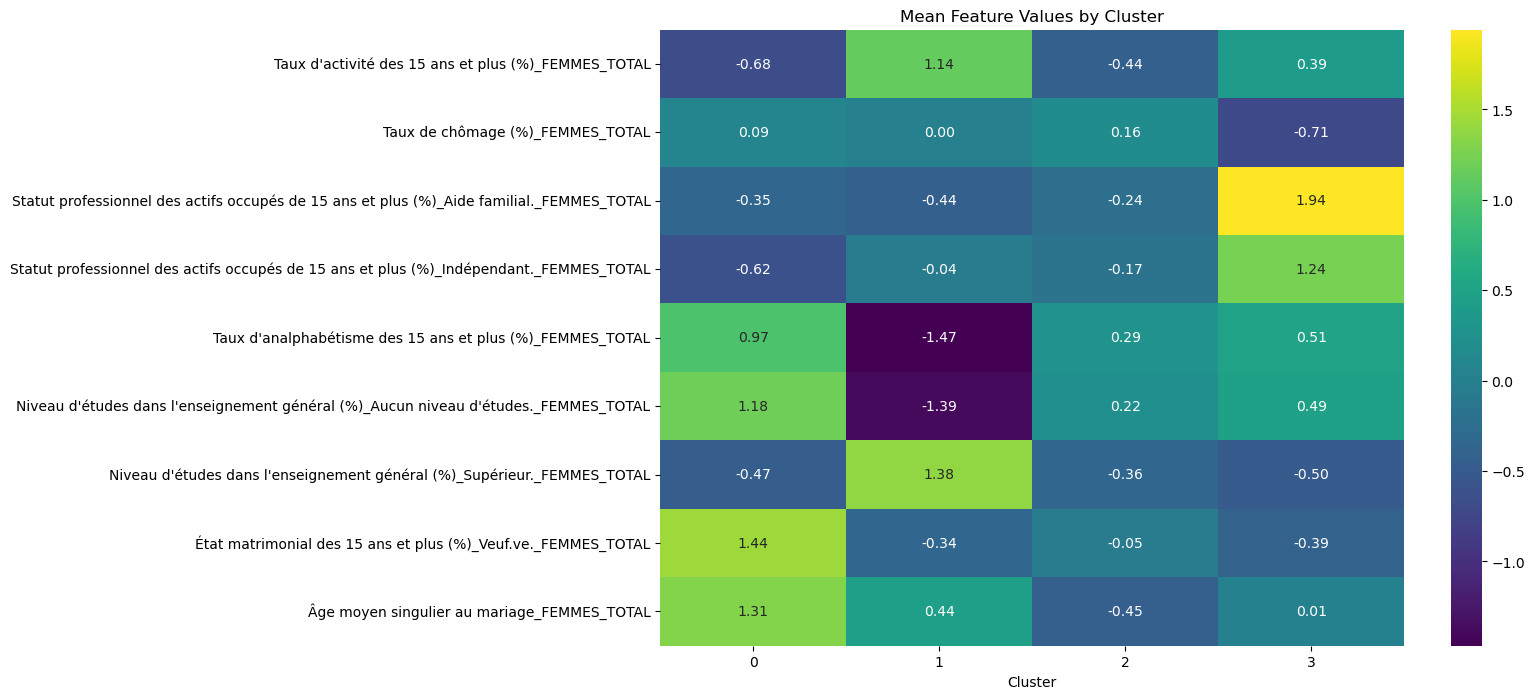

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profiles.transpose(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Mean Feature Values by Cluster')
plt.show()

- **Interpretation**

1. cluster 0:
- extremely high illitracy :Taux d'analphabétisme is very high (0.97)
- no education: Aucun niveau d'études is also very high (1.18)
- low Economic activity: Taux d'activité is low (-0.68)
- high widowhood: Veuve is extremely high (1.44), often a key vulnerability factor
- High Age at Marriage: Âge moyen singulier au mariage is high (a bit counter intuitive)
  
==> this cluster represents the most vulnerable communes. wome in these area suffer from a severe lack of education and are largely excluded from the formal economy. these are likely rural, isolated communes.


2. cluster 1:
- very low illitracy :Taux d'analphabétisme is very low (-1.47)
- very low "no education": Aucun niveau d'études is also very low (-1.39)
- good higher education level: Niveau d'études... Supérieur is very high (1.38).
- high Economic activity: Taux d'activité is high
- low unemployement: Taux de chômage is average (0.00), which is good in the context of high activity.
  
==> this cluster represents communes where women are highly educated and actively participating in the economy, there are likely urban and peri-urban centers where educational and economic opportunities are abundant


3. cluster 2:
- almost all indicators are close to average (values are between -0.45 and 0.29), with taux de chômage (-0.44) and Niveau d'études..Supérieur (-0.36) slightly better than average.
  
==> this cluster represents the "typical" Moroccan commune. 

4. cluster 4:
   - extremely high precarious work: Aide familial (1.94) and Indépendant (1.24)
   - very low unemployement:Taux de chômage is the lowest of all clusters (-0.71)
   - average education: Illiteracy and education levels are all close to the average.

==>this cluster represents communes where women are likely working in highly precarious, informal ,unpaid or underpaid roles(as family help or informal independents). which explains the offcial unemployement rate being very low.

## Part 2: Supervised Learning (Interpretable Regression)

### 2-1 Load Data 


In [12]:
y = pd.read_csv('../data/communal_target_fevi.csv', index_col=0).squeeze()
X = pd.read_csv('../data/communal_features_for_fevi_prediction.csv', index_col=0)

- **Split data into training and testing sets**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Prediction data loaded and split successfully")

Prediction data loaded and split successfully


### 2-2 Running and Logging Experiments

- **1. Simple Linear Regression (as a baseline)**

In [14]:
with mlflow.start_run(run_name="Baseline Linear Regression"):
    mlflow.log_param("model_type", "LinearRegression")
    
    # Train
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    # Evaluate
    y_pred = lr.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Log metrics
    mlflow.log_metric("r2_score", r2)
    mlflow.log_metric("mae", mae)
    
    # Provide an input example (take one row from X_test)
    input_example = X_test[:1]

    # Log model (use 'name' instead of artifact_path)
    mlflow.sklearn.log_model(
        sk_model=lr,
        name="linear_regression_model",
        input_example=input_example
    )
    
    print(f"Linear Regression R2: {r2:.3f}")


Linear Regression R2: 0.961


- **2.Random Forest Regressor (for feature importance)**

In [15]:
with mlflow.start_run(run_name="Random Forest"):
    # Define parameters
    n_estimators = 150
    max_depth = 10
    
    # Log parameters
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    
    # Train
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )
    rf.fit(X_train, y_train)
    
    # Evaluate
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Log metrics
    mlflow.log_metric("r2_score", r2)
    mlflow.log_metric("mae", mae)
    
    # Provide an input example (one row from X_test)
    input_example = X_test[:1]
    
    # Log model with new MLflow style
    mlflow.sklearn.log_model(
        sk_model=rf,
        name="random_forest_model",
        input_example=input_example
    )
    
    print(f"Random Forest R2: {r2:.3f}")


Random Forest R2: 0.932


## 2.3 Analyze and Interpret the Best Model

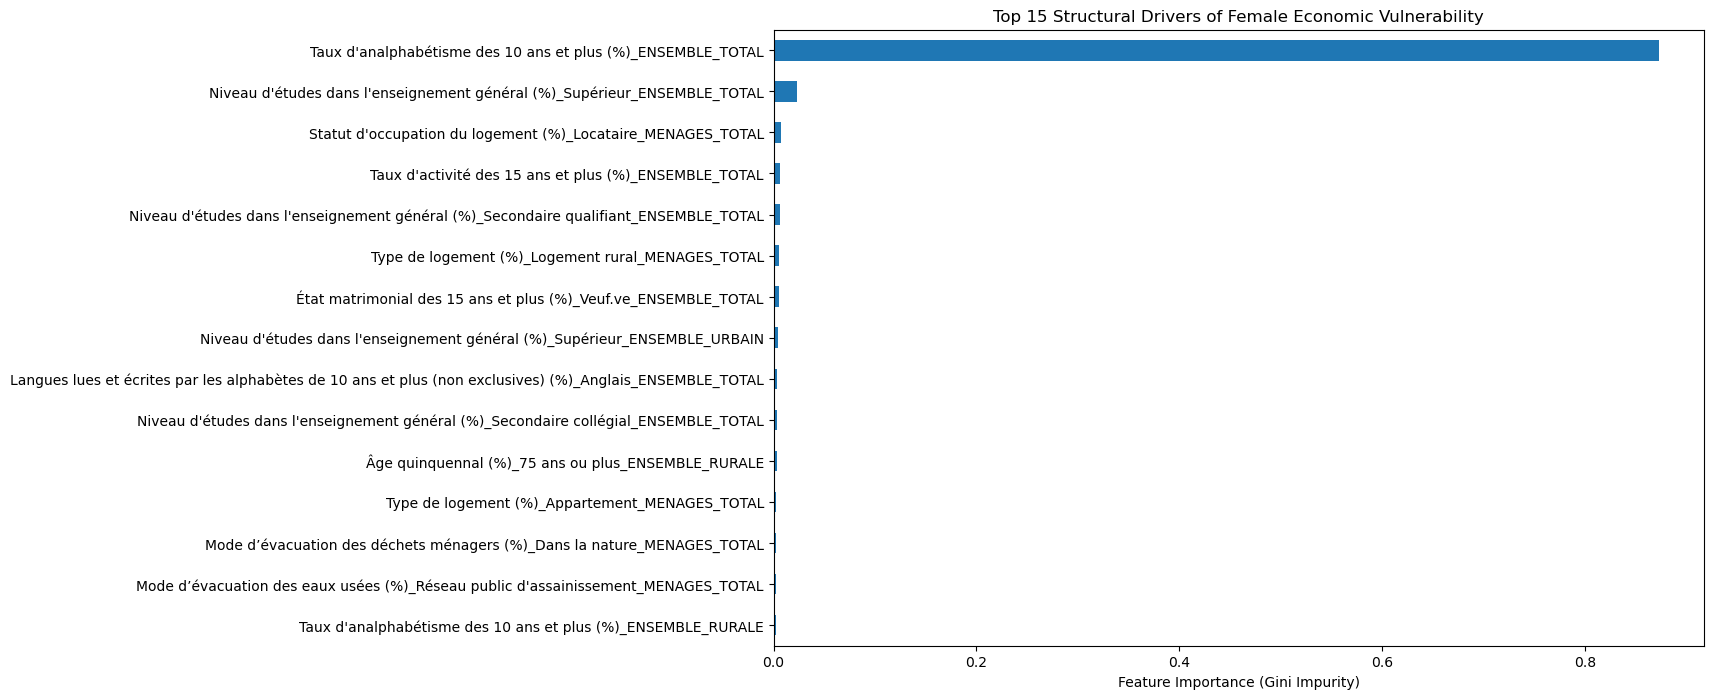

In [18]:
#assumin random forest was the best
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot the top 15 most important features
plt.figure(figsize=(12, 8))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Structural Drivers of Female Economic Vulnerability')
plt.xlabel('Feature Importance (Gini Impurity)')
plt.show()


the most powerful structural driver of female economic vulnerability is the overall communal illiteracy rate (correlation of 0.92). This indicates that while women face unique economic challenges, these challenges are most severe in communities where the general level of education is lowest. Therefore, broad-based educational initiatives appear to be the most critical and effective lever for improving women's economic outcomes.